In [39]:
from google.colab import files
uploaded = files.upload()

Saving StudentsPerformance.csv to StudentsPerformance (1).csv


In [40]:
import pandas as pd
df = pd.read_csv('StudentsPerformance.csv')
print("Loaded! Shape:", df.shape)

Loaded! Shape: (1000, 8)


In [ ]:
# Step 1 — Environment Setup & Library Verification
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("=" * 40)
print(f"{'Library':<15} {'Version'}")
print("=" * 40)
print(f"{'NumPy':<15} {np.__version__}")
print(f"{'Pandas':<15} {pd.__version__}")
print(f"{'Matplotlib':<15} {plt.matplotlib.__version__}")
print(f"{'Seaborn':<15} {sns.__version__}")
print("=" * 40)

Library         Version
NumPy           2.0.2
Pandas          2.2.2
Matplotlib      3.10.0
Seaborn         0.13.2


In [ ]:
# Step 2 — Load and Preview Dataset
df = pd.read_csv('StudentsPerformance.csv')

print("=" * 60)
print("FIRST 10 ROWS:")
print("=" * 60)
print(df.head(10))

print("=" * 60)
print("LAST 5 ROWS:")
print("=" * 60)
print(df.tail(5))

print("=" * 60)
print("RANDOM SAMPLE OF 8 ROWS:")
print("=" * 60)

print(df.sample(8, random_state=42))

FIRST 10 ROWS:
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   
5  female        group B          associate's degree      standard   
6  female        group B                some college      standard   
7    male        group B                some college  free/reduced   
8    male        group D                 high school  free/reduced   
9  female        group B                 high school  free/reduced   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2   

In [ ]:
# Step 3 — Dataset Structure Analysis
print("Shape (rows, columns):", df.shape)

print("\n--- df.info() ---")
df.info()

print("\n--- Data Types ---")
print(df.dtypes)

print("\n--- Column Names ---")
print(df.columns.tolist())

cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = df.select_dtypes(include='number').columns.tolist()
print(f"\nCategorical columns ({len(cat_cols)}): {cat_cols}")
print(f"Numerical columns ({len(num_cols)}): {num_cols}")

Shape (rows, columns): (1000, 8)

--- df.info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB

--- Data Types ---
gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score  

Missing values per column:
                             Missing Count  Percentage %
gender                                   0           0.0
race/ethnicity                           0           0.0
parental level of education              0           0.0
lunch                                    0           0.0
test preparation course                  0           0.0
math score                               0           0.0
reading score                            0           0.0
writing score                            0           0.0

Total duplicate rows: 0


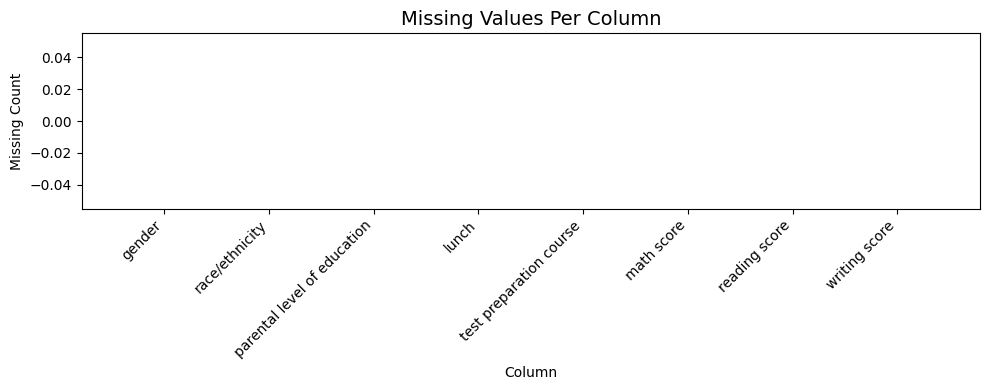

In [41]:
# Step 4 — Missing Value & Duplicate Analysis
print("Missing values per column:")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage %': missing_pct})
print(missing_df)

print(f"\nTotal duplicate rows: {df.duplicated().sum()}")

plt.figure(figsize=(10, 4))
plt.bar(df.columns, df.isnull().sum(), color='slategray')
plt.title('Missing Values Per Column', fontsize=14)
plt.xlabel('Column')
plt.ylabel('Missing Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Step 5 — Descriptive Statistics
score_cols = ['math score', 'reading score', 'writing score']

print("--- df.describe() ---")
print(df.describe())

stats_data = {}
for col in score_cols:
    stats_data[col] = {
        'Mean':     round(df[col].mean(), 2),
        'Median':   df[col].median(),
        'Mode':     df[col].mode()[0],
        'Std Dev':  round(df[col].std(), 2),
        'Variance': round(df[col].var(), 2),
        'Min':      df[col].min(),
        'Max':      df[col].max(),
        'Range':    df[col].max() - df[col].min()
    }

stats_df = pd.DataFrame(stats_data).T
print("\n--- Custom Summary Statistics Table ---")
print(stats_df)

--- df.describe() ---
       math score  reading score  writing score
count  1000.00000    1000.000000    1000.000000
mean     66.08900      69.169000      68.054000
std      15.16308      14.600192      15.195657
min       0.00000      17.000000      10.000000
25%      57.00000      59.000000      57.750000
50%      66.00000      70.000000      69.000000
75%      77.00000      79.000000      79.000000
max     100.00000     100.000000     100.000000

--- Custom Summary Statistics Table ---
                Mean  Median  Mode  Std Dev  Variance   Min    Max  Range
math score     66.09    66.0  65.0    15.16    229.92   0.0  100.0  100.0
reading score  69.17    70.0  72.0    14.60    213.17  17.0  100.0   83.0
writing score  68.05    69.0  74.0    15.20    230.91  10.0  100.0   90.0



Column: GENDER
Counts:
gender
female    518
male      482
Name: count, dtype: int64

Percentages:
gender
female    51.8
male      48.2
Name: proportion, dtype: float64

Column: RACE/ETHNICITY
Counts:
race/ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64

Percentages:
race/ethnicity
group C    31.9
group D    26.2
group B    19.0
group E    14.0
group A     8.9
Name: proportion, dtype: float64

Column: PARENTAL LEVEL OF EDUCATION
Counts:
parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64

Percentages:
parental level of education
some college          22.6
associate's degree    22.2
high school           19.6
some high school      17.9
bachelor's degree     11.8
master's degree        5.9
Name: proportion, dtype: float64

Column: LUNCH
Counts:
lunch
standard        645


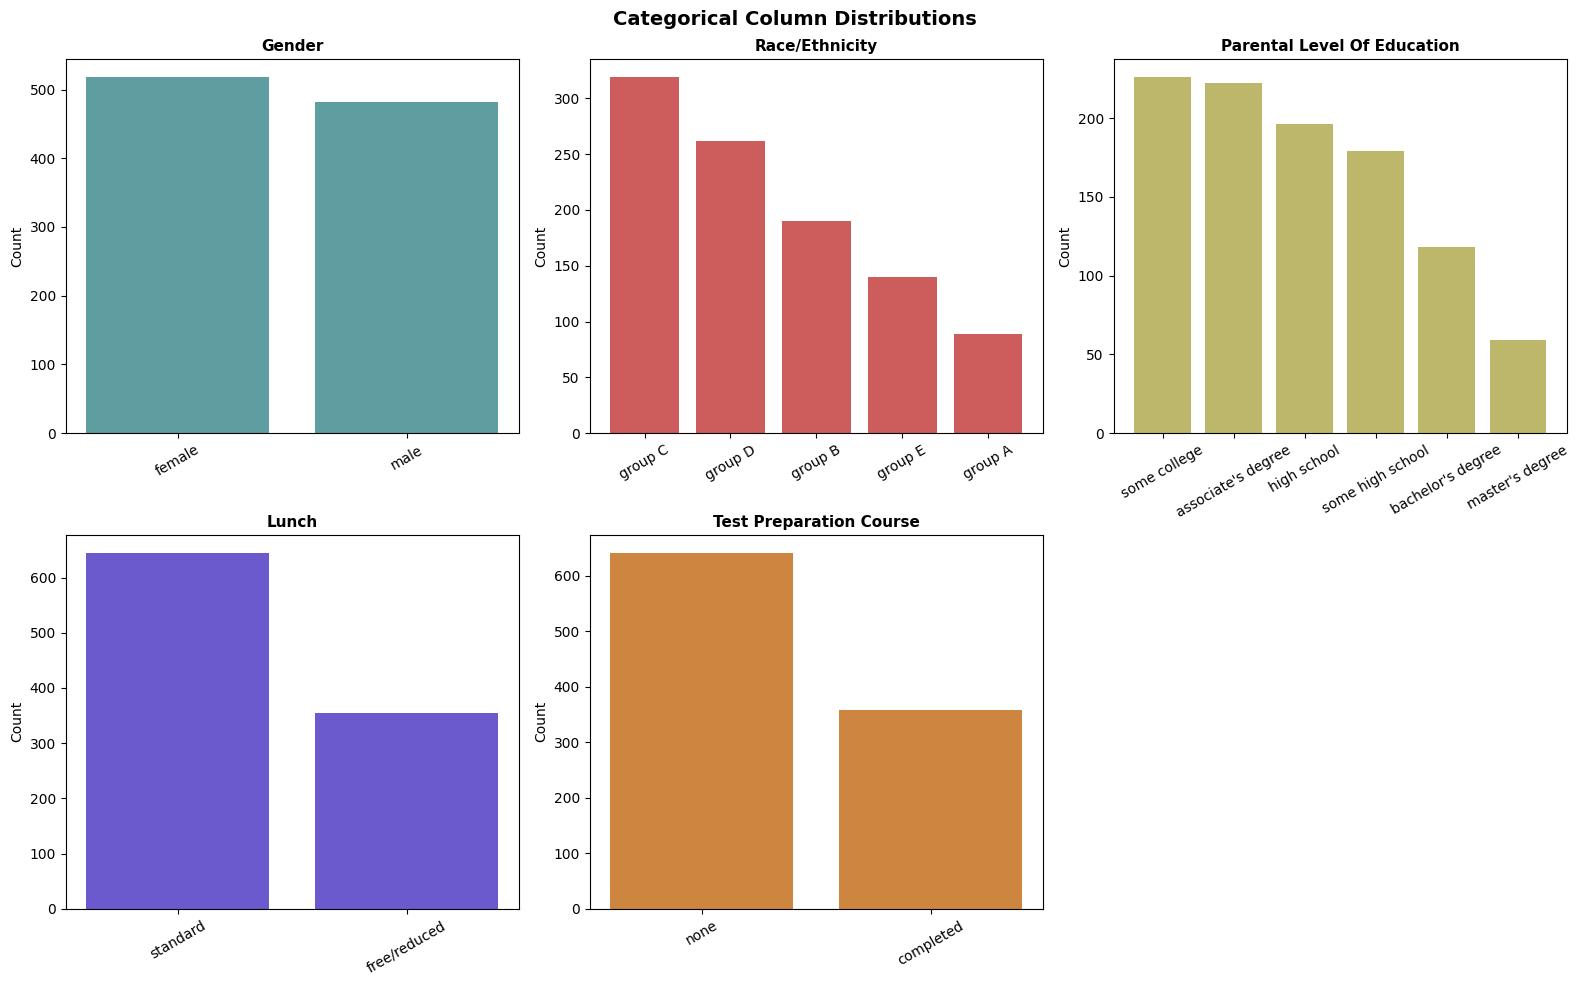

In [42]:
# Step 6 — Categorical Distribution Analysis
cat_cols = ['gender', 'race/ethnicity', 'parental level of education',
            'lunch', 'test preparation course']

for col in cat_cols:
    print(f"\n{'='*50}")
    print(f"Column: {col.upper()}")
    print(f"{'='*50}")
    print("Counts:")
    print(df[col].value_counts())
    print("\nPercentages:")

    print(df[col].value_counts(normalize=True).mul(100).round(1))

colors = ['cadetblue', 'indianred', 'darkkhaki', 'slateblue', 'peru']
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    axes[i].bar(counts.index, counts.values, color=colors[i])
    axes[i].set_title(col.title(), fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=30)

axes[5].set_visible(False)
plt.suptitle('Categorical Column Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Mean scores by: GENDER
        math score  reading score  writing score
gender                                          
female       63.63          72.61          72.47
male         68.73          65.47          63.31

Mean scores by: RACE/ETHNICITY
                math score  reading score  writing score
race/ethnicity                                          
group A              61.63          64.67          62.67
group B              63.45          67.35          65.60
group C              64.46          69.10          67.83
group D              67.36          70.03          70.15
group E              73.82          73.03          71.41

Mean scores by: PARENTAL LEVEL OF EDUCATION
                             math score  reading score  writing score
parental level of education                                          
associate's degree                67.88          70.93          69.90
bachelor's degree                 69.39          73.00          73.38
high school             

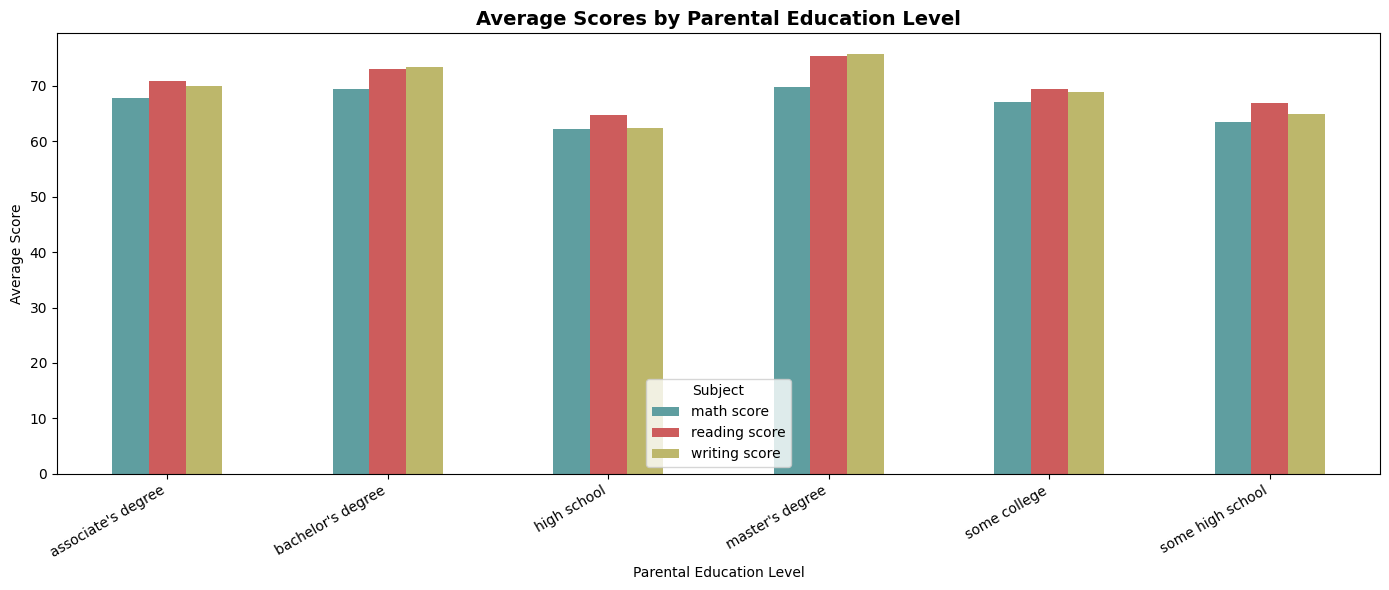

In [43]:
# Step 7 — Group Mean Score Comparisons
score_cols = ['math score', 'reading score', 'writing score']
group_cols = ['gender', 'race/ethnicity', 'parental level of education',
              'lunch', 'test preparation course']

for g in group_cols:
    print(f"\n{'='*55}")
    print(f"Mean scores by: {g.upper()}")
    print(f"{'='*55}")
    print(df.groupby(g)[score_cols].mean().round(2))

parental_scores = df.groupby('parental level of education')[score_cols].mean().round(2)
parental_scores.plot(kind='bar', figsize=(14, 6),
                     color=['cadetblue', 'indianred', 'darkkhaki'])
plt.title("Average Scores by Parental Education Level", fontsize=14, fontweight='bold')
plt.xlabel("Parental Education Level")
plt.ylabel("Average Score")
plt.xticks(rotation=30, ha='right')
plt.legend(title='Subject')
plt.tight_layout()
plt.show()

Correlation Matrix:
               math score  reading score  writing score
math score           1.00           0.82           0.80
reading score        0.82           1.00           0.95
writing score        0.80           0.95           1.00


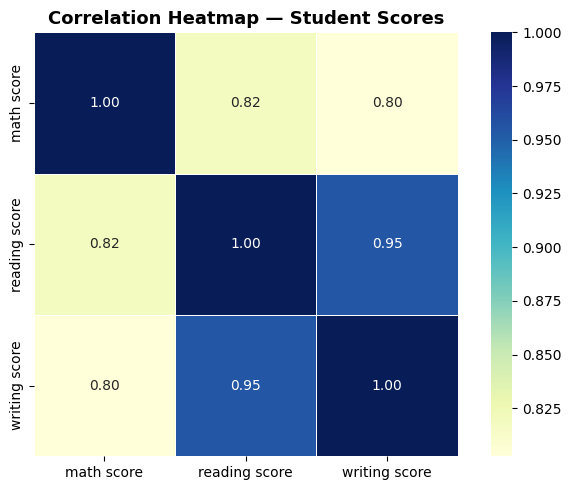


Math-Reading Pearson correlation:   0.818
Reading-Writing Pearson correlation: 0.955


In [44]:
# Step 8 — Correlation Analysis & Heatmap
score_cols = ['math score', 'reading score', 'writing score']

corr_matrix = df[score_cols].corr()
print("Correlation Matrix:")
print(corr_matrix.round(2))

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='YlGnBu',
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap — Student Scores', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

r1 = df['math score'].corr(df['reading score'])
r2 = df['reading score'].corr(df['writing score'])
print(f"\nMath-Reading Pearson correlation:   {r1:.3f}")
print(f"Reading-Writing Pearson correlation: {r2:.3f}")

=== COMPLETED TEST PREP ===
Mean: math score       69.70
reading score    73.89
writing score    74.42
dtype: float64
Std:  math score       14.44
reading score    13.64
writing score    13.38
dtype: float64

=== NO TEST PREP ===
Mean: math score       64.08
reading score    66.53
writing score    64.50
dtype: float64
Std:  math score       15.19
reading score    14.46
writing score    15.00
dtype: float64

=== IMPROVEMENT % WITH TEST PREP ===
math score: +8.8%
reading score: +11.1%
writing score: +15.4%


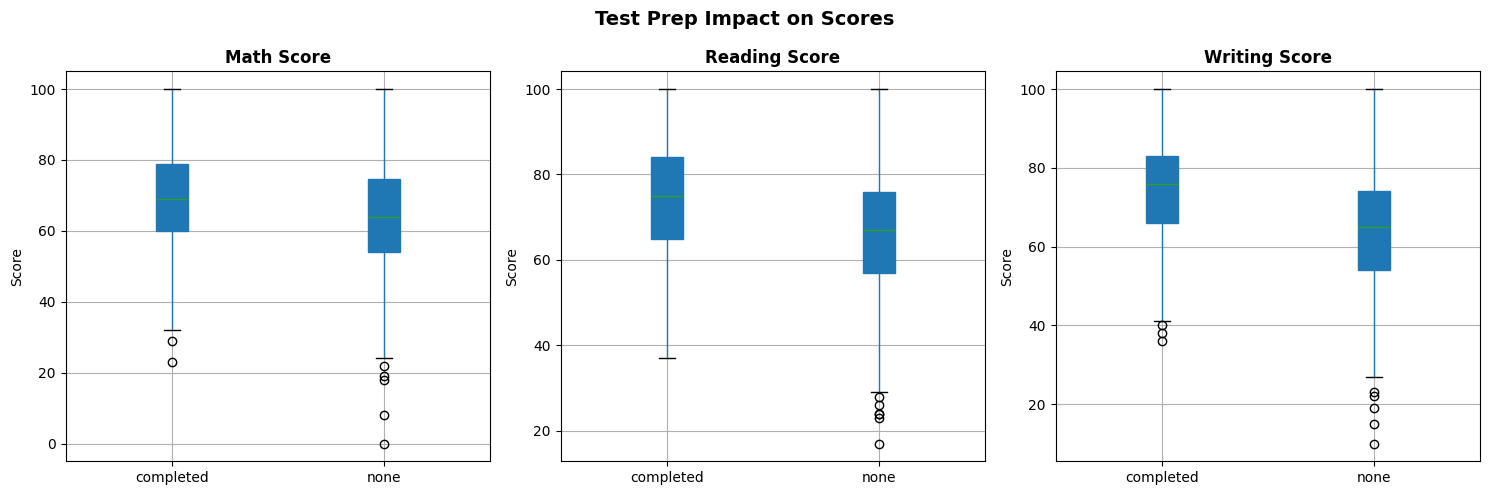

In [45]:
# Step 9 — Test Prep Impact Analysis
score_cols = ['math score', 'reading score', 'writing score']

completed = df[df['test preparation course'] == 'completed']
no_prep   = df[df['test preparation course'] == 'none']

print("=== COMPLETED TEST PREP ===")
print("Mean:", completed[score_cols].mean().round(2))
print("Std: ", completed[score_cols].std().round(2))

print("\n=== NO TEST PREP ===")
print("Mean:", no_prep[score_cols].mean().round(2))
print("Std: ", no_prep[score_cols].std().round(2))

print("\n=== IMPROVEMENT % WITH TEST PREP ===")
for col in score_cols:
    improvement = (completed[col].mean() - no_prep[col].mean()) / no_prep[col].mean() * 100
    print(f"{col}: +{improvement:.1f}%")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, col in enumerate(score_cols):
    df.boxplot(column=col, by='test preparation course',
               ax=axes[i], patch_artist=True)
    axes[i].set_title(col.title(), fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Score')

plt.suptitle('Test Prep Impact on Scores', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

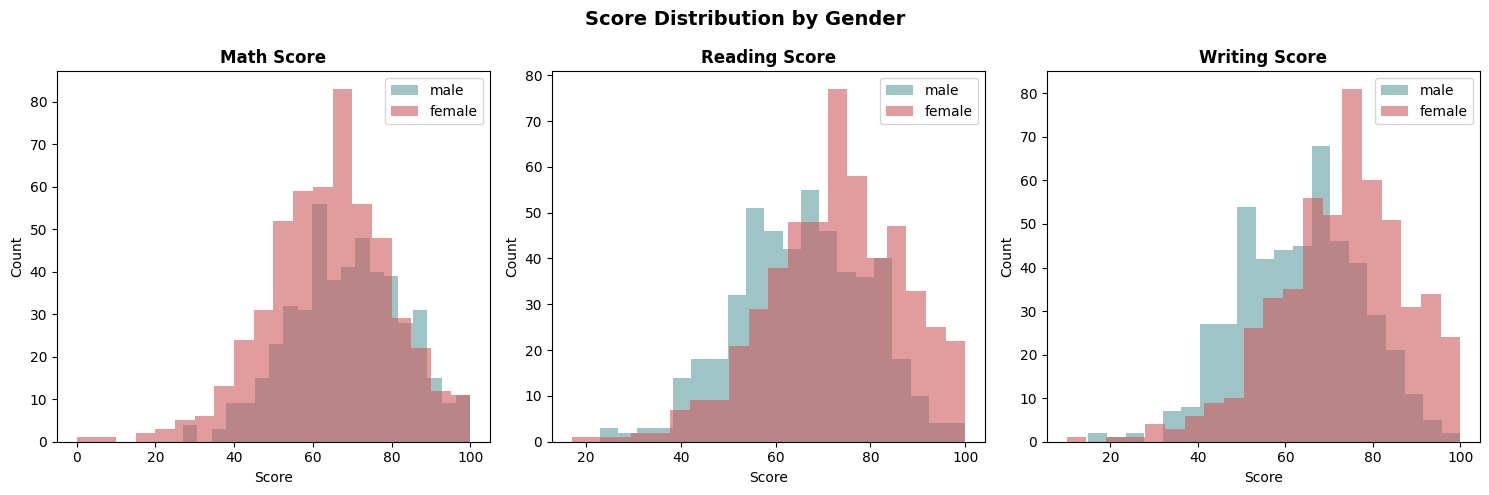

=== % of Students Scoring Above 70 ===
               male  female
math score     45.9    32.8
reading score  38.4    58.3
writing score  32.2    58.1


In [46]:
# Step 10 — Gender Score Deep-Dive
score_cols = ['math score', 'reading score', 'writing score']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, col in enumerate(score_cols):
    for gender, color in zip(['male', 'female'], ['cadetblue', 'indianred']):
        subset = df[df['gender'] == gender][col]
        axes[i].hist(subset, alpha=0.6, label=gender, color=color, bins=20)
    axes[i].set_title(col.title(), fontweight='bold')
    axes[i].set_xlabel('Score')
    axes[i].set_ylabel('Count')
    axes[i].legend()

plt.suptitle('Score Distribution by Gender', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("=== % of Students Scoring Above 70 ===")
summary = {}
for gender in ['male', 'female']:
    g = df[df['gender'] == gender]
    summary[gender] = {col: round((g[col] > 70).mean() * 100, 1)
                       for col in score_cols}

summary_df = pd.DataFrame(summary)
print(summary_df)

In [49]:
# Step 11 — Feature Engineering — 5 New Columns

df['total_score'] = df['math score'] + df['reading score'] + df['writing score']

df['average_score'] = (df['total_score'] / 3).round(2)

def assign_grade(avg):
    if avg >= 80:   return 'A'
    elif avg >= 70: return 'B'
    elif avg >= 60: return 'C'
    elif avg >= 50: return 'D'
    else:           return 'F'

df['performance_grade'] = df['average_score'].apply(assign_grade)

df['high_achiever'] = df['average_score'] >= 80

df['lowest_subject'] = df[['math score', 'reading score', 'writing score']].idxmin(axis=1)

print("=== FIRST 10 ROWS WITH NEW COLUMNS ===")
print(df.head(10))

print("\n=== GRADE DISTRIBUTION ===")
print(df['performance_grade'].value_counts())

print("\n=== LOWEST SUBJECT DISTRIBUTION ===")
print(df['lowest_subject'].value_counts())

=== FIRST 10 ROWS WITH NEW COLUMNS ===
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   
5  female        group B          associate's degree      standard   
6  female        group B                some college      standard   
7    male        group B                some college  free/reduced   
8    male        group D                 high school  free/reduced   
9  female        group B                 high school  free/reduced   

  test preparation course  math score  reading score  writing score  \
0                    none          72             72             74   
1               completed          69           

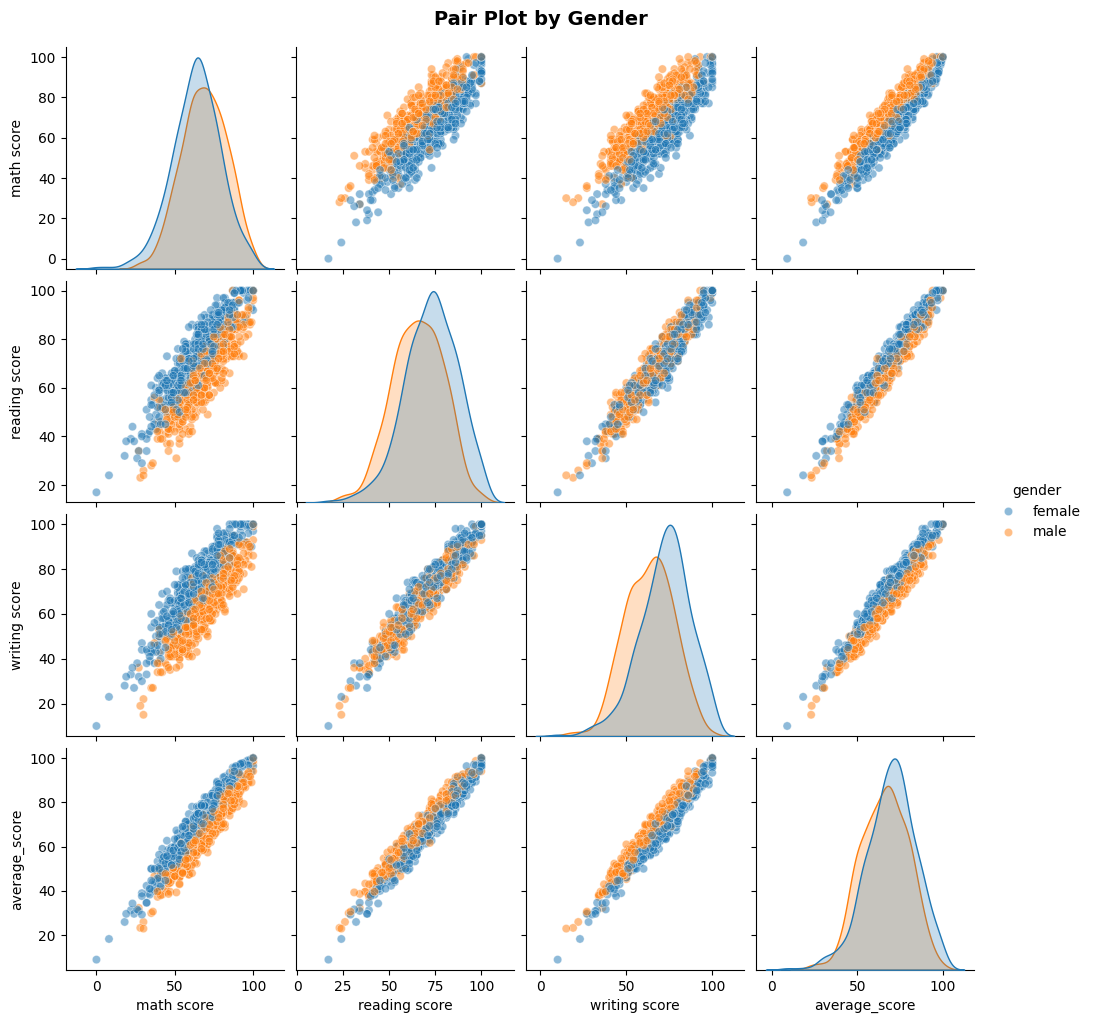

pairplot_scores.png saved!


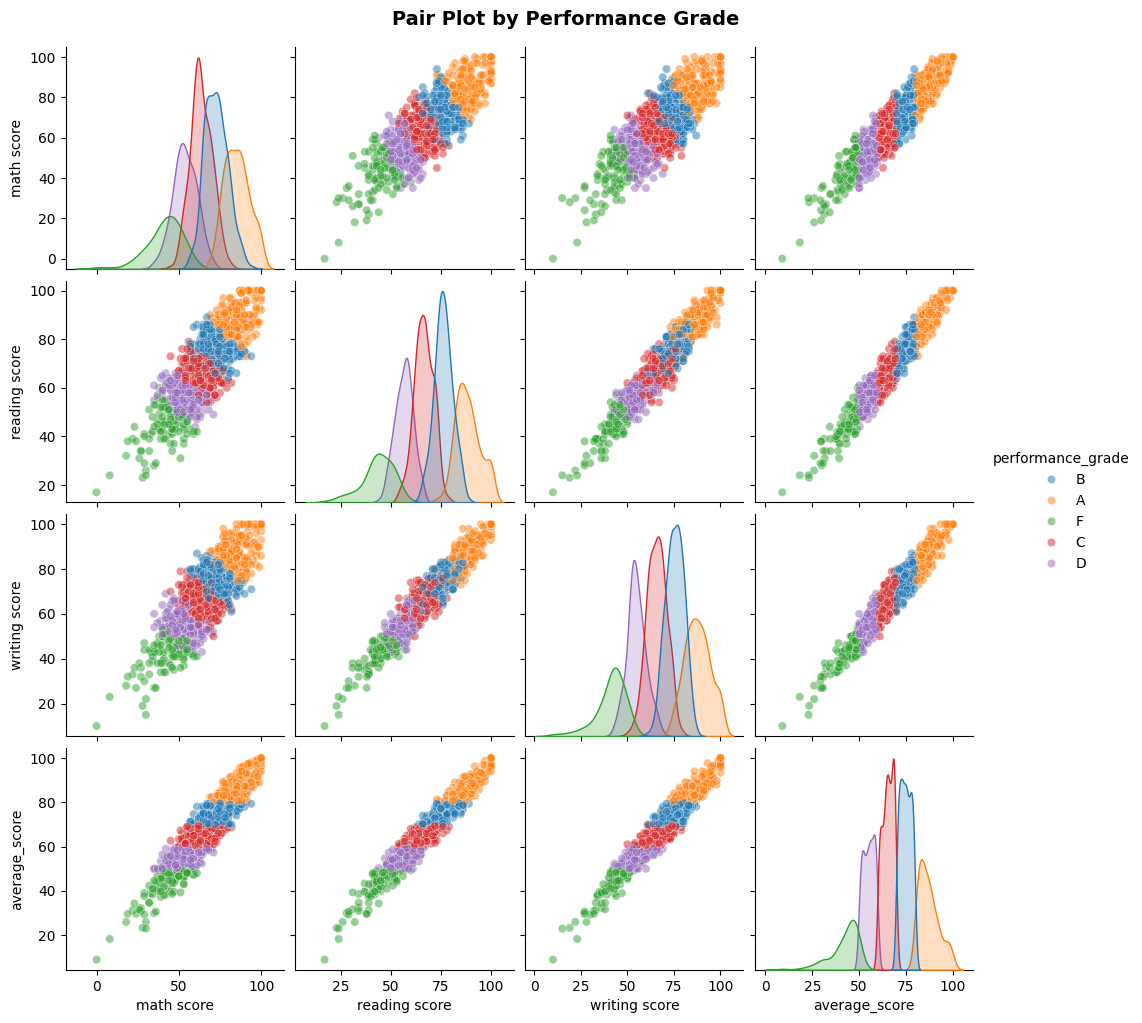

pairplot_grades.png saved!


In [50]:
# Step 12 — Pair Plot Multi-Variable Analysis
plot_cols = ['math score', 'reading score', 'writing score', 'average_score']

g1 = sns.pairplot(df[plot_cols + ['gender']],
                  hue='gender',
                  plot_kws=dict(alpha=0.5))
g1.fig.suptitle('Pair Plot by Gender', y=1.02, fontsize=14, fontweight='bold')
plt.savefig('pairplot_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print("pairplot_scores.png saved!")

g2 = sns.pairplot(df[plot_cols + ['performance_grade']],
                  hue='performance_grade',
                  plot_kws=dict(alpha=0.5))
g2.fig.suptitle('Pair Plot by Performance Grade', y=1.02, fontsize=14, fontweight='bold')
plt.savefig('pairplot_grades.png', dpi=150, bbox_inches='tight')
plt.show()
print("pairplot_grades.png saved!")

=== PIVOT 1: Parental Education x Gender → Avg Score ===
gender                       female   male
parental level of education               
associate's degree            71.12  67.87
bachelor's degree             74.67  68.78
high school                   64.75  61.58
master's degree               73.65  73.52
some college                  71.00  65.72
some high school              65.56  64.64


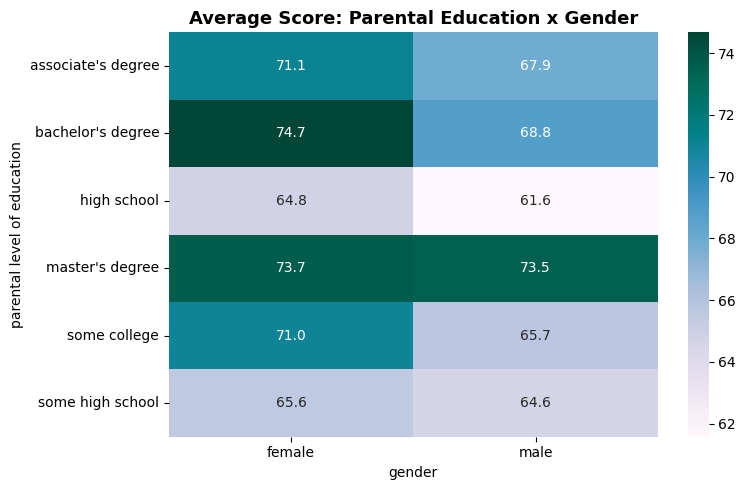


=== PIVOT 2: Race/Ethnicity x Test Prep → Math Score ===
test preparation course  completed   none
race/ethnicity                           
group A                      68.26  58.09
group B                      67.19  61.37
group C                      67.50  62.71
group D                      69.79  66.26
group E                      77.43  71.11


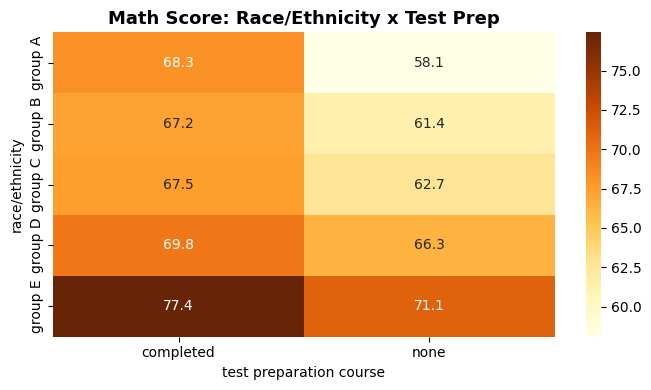

In [51]:
# Step 13 — Pivot Tables & Advanced Grouping

pivot1 = df.pivot_table(
    index='parental level of education',
    columns='gender',
    values='average_score',
    aggfunc='mean'
).round(2)
print("=== PIVOT 1: Parental Education x Gender → Avg Score ===")
print(pivot1)

# heatmap makes it easier to spot where the gender gap is largest
plt.figure(figsize=(8, 5))
sns.heatmap(pivot1, annot=True, fmt='.1f', cmap='PuBuGn')
plt.title("Average Score: Parental Education x Gender",
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

pivot2 = df.pivot_table(
    index='race/ethnicity',
    columns='test preparation course',
    values='math score',
    aggfunc='mean'
).round(2)

print("\n=== PIVOT 2: Race/Ethnicity x Test Prep → Math Score ===")
print(pivot2)

plt.figure(figsize=(7, 4))
sns.heatmap(pivot2, annot=True, fmt='.1f', cmap='YlOrBr')
plt.title("Math Score: Race/Ethnicity x Test Prep",
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

=== score_summary ===

math score:
{'mean': np.float64(66.09), 'median': 66.0, 'std': 15.16, 'min': 0, 'max': 100, 'pct_above_70': np.float64(39.1)}

reading score:
{'mean': np.float64(69.17), 'median': 70.0, 'std': 14.6, 'min': 17, 'max': 100, 'pct_above_70': np.float64(48.7)}

writing score:
{'mean': np.float64(68.05), 'median': 69.0, 'std': 15.2, 'min': 10, 'max': 100, 'pct_above_70': np.float64(45.6)}

=== plot_distribution ===


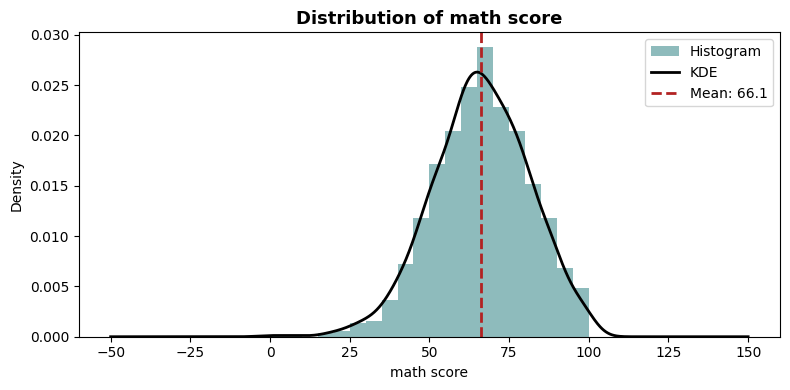

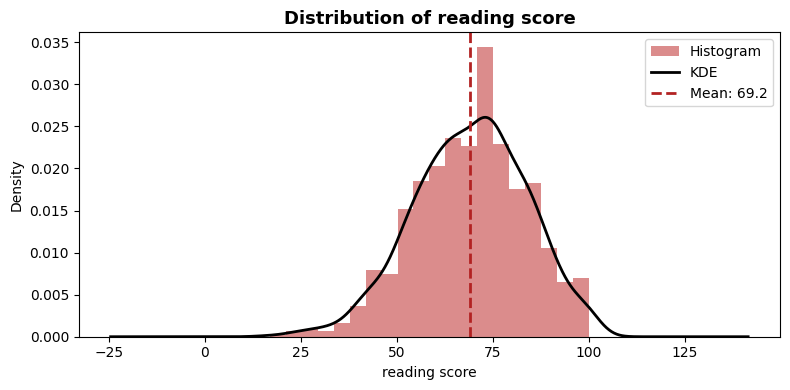

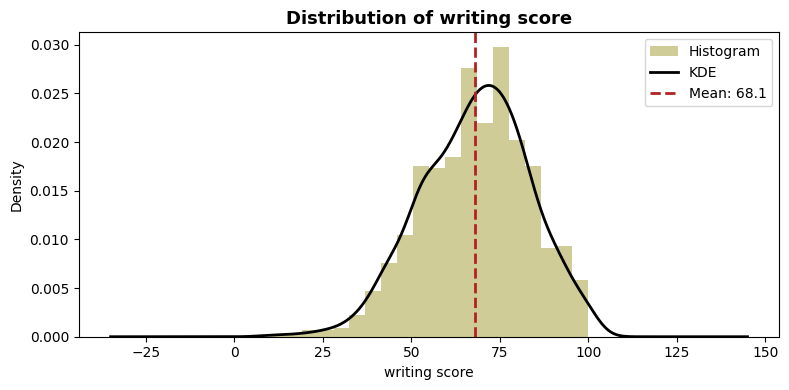


=== compare_groups ===
Gender vs Writing Score:
   gender  mean_score  pct_above_70
0  female       72.47          58.1
1    male       63.31          32.2

Race/Ethnicity vs Math Score:
  race/ethnicity  mean_score  pct_above_70
0        group E       73.82          61.4
1        group D       67.36          43.5
2        group C       64.46          32.6
3        group B       63.45          32.6
4        group A       61.63          28.1


In [52]:
# Step 14 — Three Reusable Python Functions

def score_summary(df, col):
    """
    Returns basic summary statistics for a numeric column.
    Includes pct_above_70 which describe() doesn't give you by default.
    Parameters: df (DataFrame), col (str) - column name
    Returns: dict
    """
    return {
        'mean':         round(df[col].mean(), 2),
        'median':       df[col].median(),
        'std':          round(df[col].std(), 2),
        'min':          df[col].min(),
        'max':          df[col].max(),
        'pct_above_70': round((df[col] > 70).mean() * 100, 1)
    }

def plot_distribution(df, col, color='cadetblue'):
    """
    Plots a histogram with a KDE curve and a vertical mean line.
    Parameters: df (DataFrame), col (str), color (str)
    """
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(df[col], bins=20, color=color, alpha=0.7,
            density=True, label='Histogram')
    df[col].plot.kde(ax=ax, color='black', linewidth=2, label='KDE')
    # axvline draws a vertical line at the mean position
    ax.axvline(df[col].mean(), color='firebrick', linestyle='--', linewidth=2,
               label=f'Mean: {df[col].mean():.1f}')
    ax.set_title(f'Distribution of {col}', fontsize=13, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.legend()
    plt.tight_layout()
    plt.show()

def compare_groups(df, group_col, score_col):
    """
    Groups by a categorical column and returns mean scores + % above 70,
    sorted from highest to lowest mean.
    Parameters: df (DataFrame), group_col (str), score_col (str)
    Returns: DataFrame
    """
    result = df.groupby(group_col)[score_col].mean().round(2).reset_index()
    result.columns = [group_col, 'mean_score']
    result['pct_above_70'] = df.groupby(group_col)[score_col].apply(
        lambda x: round((x > 70).mean() * 100, 1)).values
    return result.sort_values('mean_score', ascending=False).reset_index(drop=True)

print("=== score_summary ===")
for col in ['math score', 'reading score', 'writing score']:
    print(f"\n{col}:")
    print(score_summary(df, col))

print("\n=== plot_distribution ===")
plot_distribution(df, 'math score',    color='cadetblue')
plot_distribution(df, 'reading score', color='indianred')
plot_distribution(df, 'writing score', color='darkkhaki')

print("\n=== compare_groups ===")
print("Gender vs Writing Score:")
print(compare_groups(df, 'gender', 'writing score'))
print("\nRace/Ethnicity vs Math Score:")
print(compare_groups(df, 'race/ethnicity', 'math score'))

In [53]:
# Step 15 — NumPy Manual Statistical Computations

math_arr  = df['math score'].values
read_arr  = df['reading score'].values
write_arr = df['writing score'].values

arrays = {'Math': math_arr, 'Reading': read_arr, 'Writing': write_arr}

# (a) basic stats  +  (b) z-scores & outliers  +  (e) pass rate
print("=" * 55)
for name, arr in arrays.items():
    print(f"\n--- {name} Score ---")
    print(f"Mean:   {np.mean(arr):.2f}")
    print(f"Median: {np.median(arr):.2f}")
    print(f"Std:    {np.std(arr):.2f}")
    print(f"Var:    {np.var(arr):.2f}")
    print(f"Min:    {np.min(arr)}  |  Max: {np.max(arr)}")

    z = (arr - np.mean(arr)) / np.std(arr)
    outliers = np.sum((z > 2) | (z < -2))
    print(f"Outliers (|z| > 2): {outliers} students")

    pass_rate = np.mean(arr > 70) * 100
    print(f"Pass rate (score > 70): {pass_rate:.1f}%")

# (c) percentile table — 3 subjects x 5 percentiles
print("\n=== Percentile Table ===")
percentiles = [10, 25, 50, 75, 90]
pct_data = {}
for name, arr in arrays.items():
    pct_data[name] = np.percentile(arr, percentiles)

pct_df = pd.DataFrame(pct_data, index=[f'P{p}' for p in percentiles])
print(pct_df)

# (d) top 10 math scorers
# np.argsort returns indices in ascending order so I slice the last 10 and flip with [::-1]
print("\n=== TOP 10 MATH SCORERS ===")
top10_idx = np.argsort(math_arr)[-10:][::-1]
print("Indices:", top10_idx)
print("Scores: ", math_arr[top10_idx])
top10_df = df.iloc[top10_idx][['gender', 'math score',
                                'reading score', 'writing score',
                                'average_score']].reset_index(drop=True)
print(top10_df)


--- Math Score ---
Mean:   66.09
Median: 66.00
Std:    15.16
Var:    229.69
Min:    0  |  Max: 100
Outliers (|z| > 2): 46 students
Pass rate (score > 70): 39.1%

--- Reading Score ---
Mean:   69.17
Median: 70.00
Std:    14.59
Var:    212.95
Min:    17  |  Max: 100
Outliers (|z| > 2): 46 students
Pass rate (score > 70): 48.7%

--- Writing Score ---
Mean:   68.05
Median: 69.00
Std:    15.19
Var:    230.68
Min:    10  |  Max: 100
Outliers (|z| > 2): 42 students
Pass rate (score > 70): 45.6%

=== Percentile Table ===
     Math  Reading  Writing
P10  47.0     51.0    48.00
P25  57.0     59.0    57.75
P50  66.0     70.0    69.00
P75  77.0     79.0    79.00
P90  86.0     87.1    87.00

=== TOP 10 MATH SCORERS ===
Indices: [916 458 962 625 623 451 149 306 114 263]
Scores:  [100 100 100 100 100 100 100  99  99  99]
   gender  math score  reading score  writing score  average_score
0    male         100            100            100         100.00
1  female         100            100           

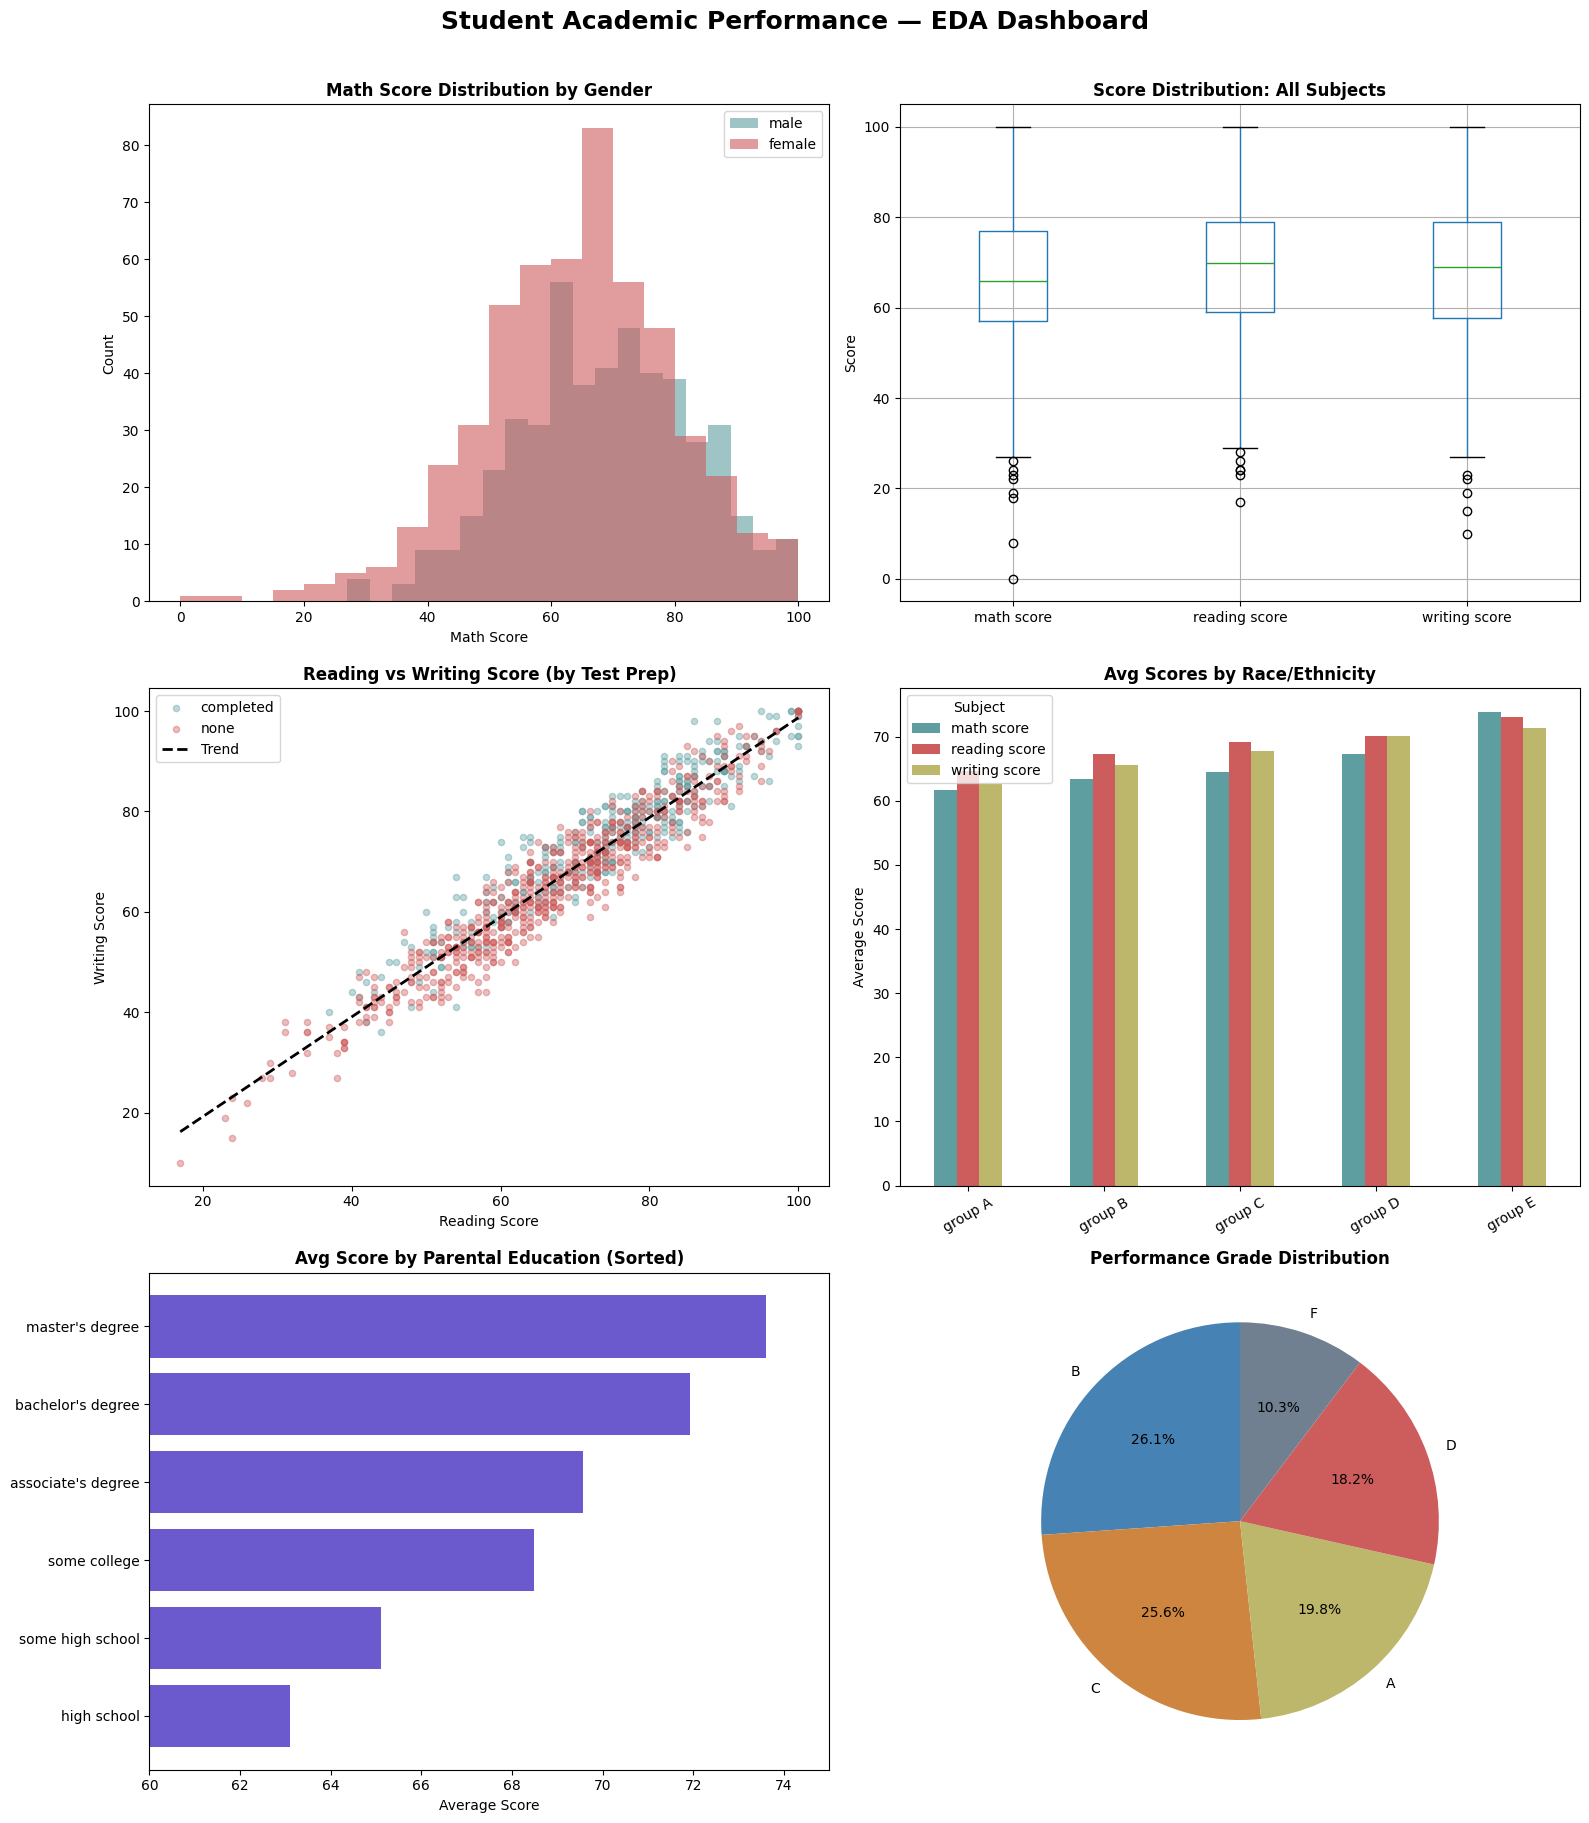

eda_dashboard.png saved!


In [54]:
# Step 16 — Professional 6-Chart EDA Dashboard
fig, axes = plt.subplots(3, 2, figsize=(16, 18))

# Chart 1: Math score histogram by gender
for gender, color in zip(['male', 'female'], ['cadetblue', 'indianred']):
    subset = df[df['gender'] == gender]['math score']
    axes[0, 0].hist(subset, alpha=0.6, label=gender, bins=20, color=color)
axes[0, 0].set_title('Math Score Distribution by Gender', fontweight='bold')
axes[0, 0].set_xlabel('Math Score')
axes[0, 0].set_ylabel('Count')
axes[0, 0].legend()

# Chart 2: Box plot for all 3 subjects side by side
df[['math score', 'reading score', 'writing score']].boxplot(ax=axes[0, 1])
axes[0, 1].set_title('Score Distribution: All Subjects', fontweight='bold')
axes[0, 1].set_ylabel('Score')

# Chart 3: Scatter reading vs writing, colored by test prep status
colors_map = {'completed': 'cadetblue', 'none': 'indianred'}
for prep, color in colors_map.items():
    sub = df[df['test preparation course'] == prep]
    axes[1, 0].scatter(sub['reading score'], sub['writing score'],
                       alpha=0.4, color=color, label=prep, s=20)

m, b = np.polyfit(df['reading score'], df['writing score'], 1)
x_line = np.linspace(df['reading score'].min(), df['reading score'].max(), 100)
axes[1, 0].plot(x_line, m * x_line + b, 'k--', linewidth=2, label='Trend')
axes[1, 0].set_title('Reading vs Writing Score (by Test Prep)', fontweight='bold')
axes[1, 0].set_xlabel('Reading Score')
axes[1, 0].set_ylabel('Writing Score')
axes[1, 0].legend()

# Chart 4: Grouped bar — race/ethnicity vs all 3 subjects
race_scores = df.groupby('race/ethnicity')[
    ['math score', 'reading score', 'writing score']].mean()
race_scores.plot(kind='bar', ax=axes[1, 1],
                 color=['cadetblue', 'indianred', 'darkkhaki'])
axes[1, 1].set_title('Avg Scores by Race/Ethnicity', fontweight='bold')
axes[1, 1].set_xlabel('')
axes[1, 1].set_ylabel('Average Score')
axes[1, 1].tick_params(axis='x', rotation=30)
axes[1, 1].legend(title='Subject')

# Chart 5: Horizontal bar — parental education sorted ascending so highest is at top
edu_scores = df.groupby('parental level of education')[
    'average_score'].mean().sort_values()
axes[2, 0].barh(edu_scores.index, edu_scores.values, color='slateblue')
axes[2, 0].set_title('Avg Score by Parental Education (Sorted)', fontweight='bold')
axes[2, 0].set_xlabel('Average Score')
axes[2, 0].set_xlim(60, 75)

# Chart 6: Pie chart of performance grade distribution
grade_counts = df['performance_grade'].value_counts()
colors_pie = ['steelblue', 'peru', 'darkkhaki', 'indianred', 'slategray']
axes[2, 1].pie(grade_counts, labels=grade_counts.index,
               autopct='%1.1f%%', colors=colors_pie, startangle=90)
axes[2, 1].set_title('Performance Grade Distribution', fontweight='bold')

plt.suptitle('Student Academic Performance — EDA Dashboard',
             fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("eda_dashboard.png saved!")

#  Analysis Report

## 1. Executive Summary

For this week's task I analyzed a dataset of 1,000 students and their exam scores in math, reading, and writing. The dataset also had background information like gender, parents' education level, lunch type, and whether the student completed a test preparation course. I went through the data step by step — checking its structure, running group comparisons, creating new features, and making visualizations.

The three main things that stood out to me were: first, students who completed test prep scored noticeably higher, especially in writing (15.4% improvement). Second, parental education level had a consistent effect on scores — students whose parents have a master's degree averaged around 73.6 while students with high school parents averaged around 63.1. Third, there's a clear gender pattern where females do better in reading and writing and males do better in math. I'll go through all of this in more detail below.

## 2. Data Quality Assessment

Honestly I was expecting to find some missing values when I checked, but the dataset turned out to be completely clean — zero missing values across all 8 columns and zero duplicate rows. I used `df.isnull().sum()` and `df.duplicated().sum()` to verify this.

The data types were also correct. The three score columns are stored as integers which makes sense, and the five background columns (gender, race/ethnicity, etc.) are stored as object type which is just how pandas stores text. One thing I noted is that for machine learning later, those text columns would need to be converted to numbers since ML algorithms can't work with raw text. I read that this is done using something called One-Hot Encoding but I haven't learned that properly yet.

## 3. Key Statistical Findings

Reading score had the highest average at 69.17, followed by writing at 68.05, and math was the lowest at 66.09. What I found more interesting than the averages was the standard deviation — math had the highest at 15.16, meaning students' math scores were the most spread out. Some scored 0 and some scored 100, which is a huge range.

The correlation between reading and writing was 0.955 which is very high — basically students who are good at reading are almost always good at writing too. Math was less correlated with both (0.818 with reading, 0.803 with writing) which makes sense since it uses different skills.

Test prep improved scores by 8.8% in math, 11.1% in reading, and 15.4% in writing. The lunch type gap also surprised me — students on standard lunch averaged 70.84 across subjects while free/reduced lunch students averaged 62.20, which is about an 8.6 point difference. I wasn't expecting economic background to show up this clearly in the numbers.

## 4. Visualization Insights

The correlation heatmap was one of the first times a visualization actually made something click for me — you can immediately see the reading-writing pair is the darkest cell (0.95) without even reading the numbers. The pair plots were the most complex charts I made and they took a while to understand. Once I figured out what I was looking at, I could see that the performance grade groups (A through F) are fairly well separated along the diagonal, which I think means a classifier could potentially predict grades from scores reasonably well.

The gender histogram showed that male math scores are shifted to the right compared to females, while for writing it's the opposite. The scatter plot of reading vs writing (Step 16, Chart 3) was probably my favourite — the points form almost a straight line and the test prep coloring adds another layer that's easy to read. The pie chart showed B and C are the most common grades, with only 19.8% of students achieving an A.

## 5. Feature Engineering Rationale

I created 5 new columns to make the data more useful for analysis. `total_score` is just the sum of all three subjects out of 300, and `average_score` divides that by 3 to bring it back to a 0-100 scale which is easier to interpret. `performance_grade` converts the average into a letter grade using the standard A/B/C/D/F cutoffs — I used a function with if/elif for this which was good practice.

`high_achiever` is a True/False column for students who average 80 or above. I think this could be useful later as a target variable for a classification model. The last one, `lowest_subject`, finds each student's weakest subject. I had to look up `idxmin()` to figure out how to do this in one line. The result showed that 552 students (55.2%) have math as their lowest subject, which lines up with math having the lowest average overall.

## 6. Actionable Recommendations for Educators

Based on what I found in the data, here are a few things that could actually help students:

The test prep program clearly works so schools should try to make it more accessible. Right now only 35.8% of students completed it. If cost or availability is a barrier, offering it free or online could increase participation and improve scores across the board.

Math needs the most attention. It has the lowest average (66.09), the lowest pass rate above 70 (39.1%), and is the weakest subject for over half the students. Some kind of dedicated math support — extra practice, tutoring, or different teaching approaches — seems necessary.

The lunch type gap of 8.6 points is significant and suggests economic background affects learning outcomes. Students on free/reduced lunch should have equal access to test prep and academic support resources, not less.

Finally, since reading and writing are so strongly linked (0.955 correlation), teaching them together in integrated literacy programs might be more efficient than treating them as completely separate subjects.

## 7. Reflection & Lessons Learned

This was genuinely a lot of work for week 1 and I'd be lying if I said everything came easily. The parts I found hardest were the NumPy section (step 15) — doing statistics manually without pandas felt unnatural at first — and getting the subplot layout right for the dashboard. I spent more time than I expected just on axes indexing (`axes[0,0]` vs `axes[1,0]` etc.).

The finding that surprised me most was the parental education gap. I expected test prep or gender to be the biggest factor but the education level of parents had the most consistent effect across all subjects — a gap of over 10 points between master's degree and high school. That's not something you can easily fix with a school program.

I also realized that EDA isn't just about running code — it's about actually reading the output and asking follow-up questions. Early on I was just running cells without thinking too much about what the numbers meant. By the end I was actually curious about things like why Group A scores lower or what's driving the lunch type gap.

Going forward I want to understand how to actually build a model on this data — like how would you use the features I engineered to predict a student's grade? That feels like the natural next step and I'm hoping we get to that in the coming weeks.